# MDTB Rest parcellations

In [3]:
from FusionModel.util import plot_data_flat, plot_multi_flat


In [4]:
# Add the directories of necessary packages to the Python path
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import IndividualParcellation.scripts.paths as paths
from IndividualParcellation.scripts.paths import base_dir
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.full_model as fm
from FusionModel.util import plot_data_flat, plot_multi_flat
import pandas as pd
import seaborn as sb
import warnings
# Ignore RuntimeWarning
warnings.filterwarnings("ignore", category=RuntimeWarning)

pt.set_default_tensor_type(pt.cuda.FloatTensor
                           if pt.cuda.is_available() else
                           pt.FloatTensor)



In [5]:
# Settings
symmetric = True # Whether to get a symmetric or asymmetric parcellation
if symmetric:
    sym_type = 'sym'

space, _ = am.get_atlas('MNISymC2')
if space.name == 'MNISymC2':
    space_folder = 'tpl-MNI152NLin2009cSymC'

atlas_dir = paths.set_atlas_dir()
data_dir = paths.set_fusion_dir()
dataset_dir = data_dir + '/MDTB'
figure_dir = paths.set_figure_dir()

atlas = 'NettekovenSym32'
model_name = f'/{space_folder}/atl-{atlas}_space-{space_folder.split("tpl-")[1]}_probseg.nii'


In [6]:
_, cmap, labels = nt.read_lut(f'{atlas_dir}/{space_folder}/atl-{atlas}.lut')
U = space.read_data(atlas_dir + model_name)
U = U.T
ar_model = ar.build_arrangement_model(U, prior_type='prob', sym_type=sym_type, atlas=space)

In [10]:
# Step 4a.1: Build the data into list of 3d tensor
mdtb_dataset = ds.get_dataset_class(data_dir,'MDTB')
subj = mdtb_dataset.get_participants().participant_id
data, info = [], []
for ses_id in mdtb_dataset.sessions:
    this_data = []
    this_info = []
    info.append(mdtb_dataset.get_info(ses_id=ses_id, type='CondHalf'))
    for i, s in enumerate(subj):
        file_name = f'{dataset_dir}/derivatives/{s}/data/{s}_space-{space.name}_{ses_id}_CondHalf.dscalar.nii'
        this_data.append(space.read_data(file_name).T)
    data.append(np.stack(this_data))
    
# Step 4a.2: Assemble condition and partition vectors
cond_v, part_v, sub_ind = [], [], []
for j, inf in enumerate(info):
    cond_v.append(inf['cond_num_uni'].values.reshape(-1,))
    part_v.append(inf['half'].values.reshape(-1,))
    sub_ind.append(np.arange(0, len(subj)))

In [11]:
# Step 4b.1: Load the data into 3d tensor
data, info, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, subj=None)

# Step 4b.2: Prepare the data into the right format
tdata, cond_v, part_v, sub_ind = fm.prep_datasets(data, info.sess,
                                                  info['cond_num_uni'].values,
                                                  info['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [12]:
indiv_par, _, _ = fm.get_indiv_parcellation(ar_model, tdata, space.name, cond_v, part_v, sub_ind, Vs=None, sym_type = sym_type)

TypeError: object of type 'AtlasVolumeSymmetric' has no len()

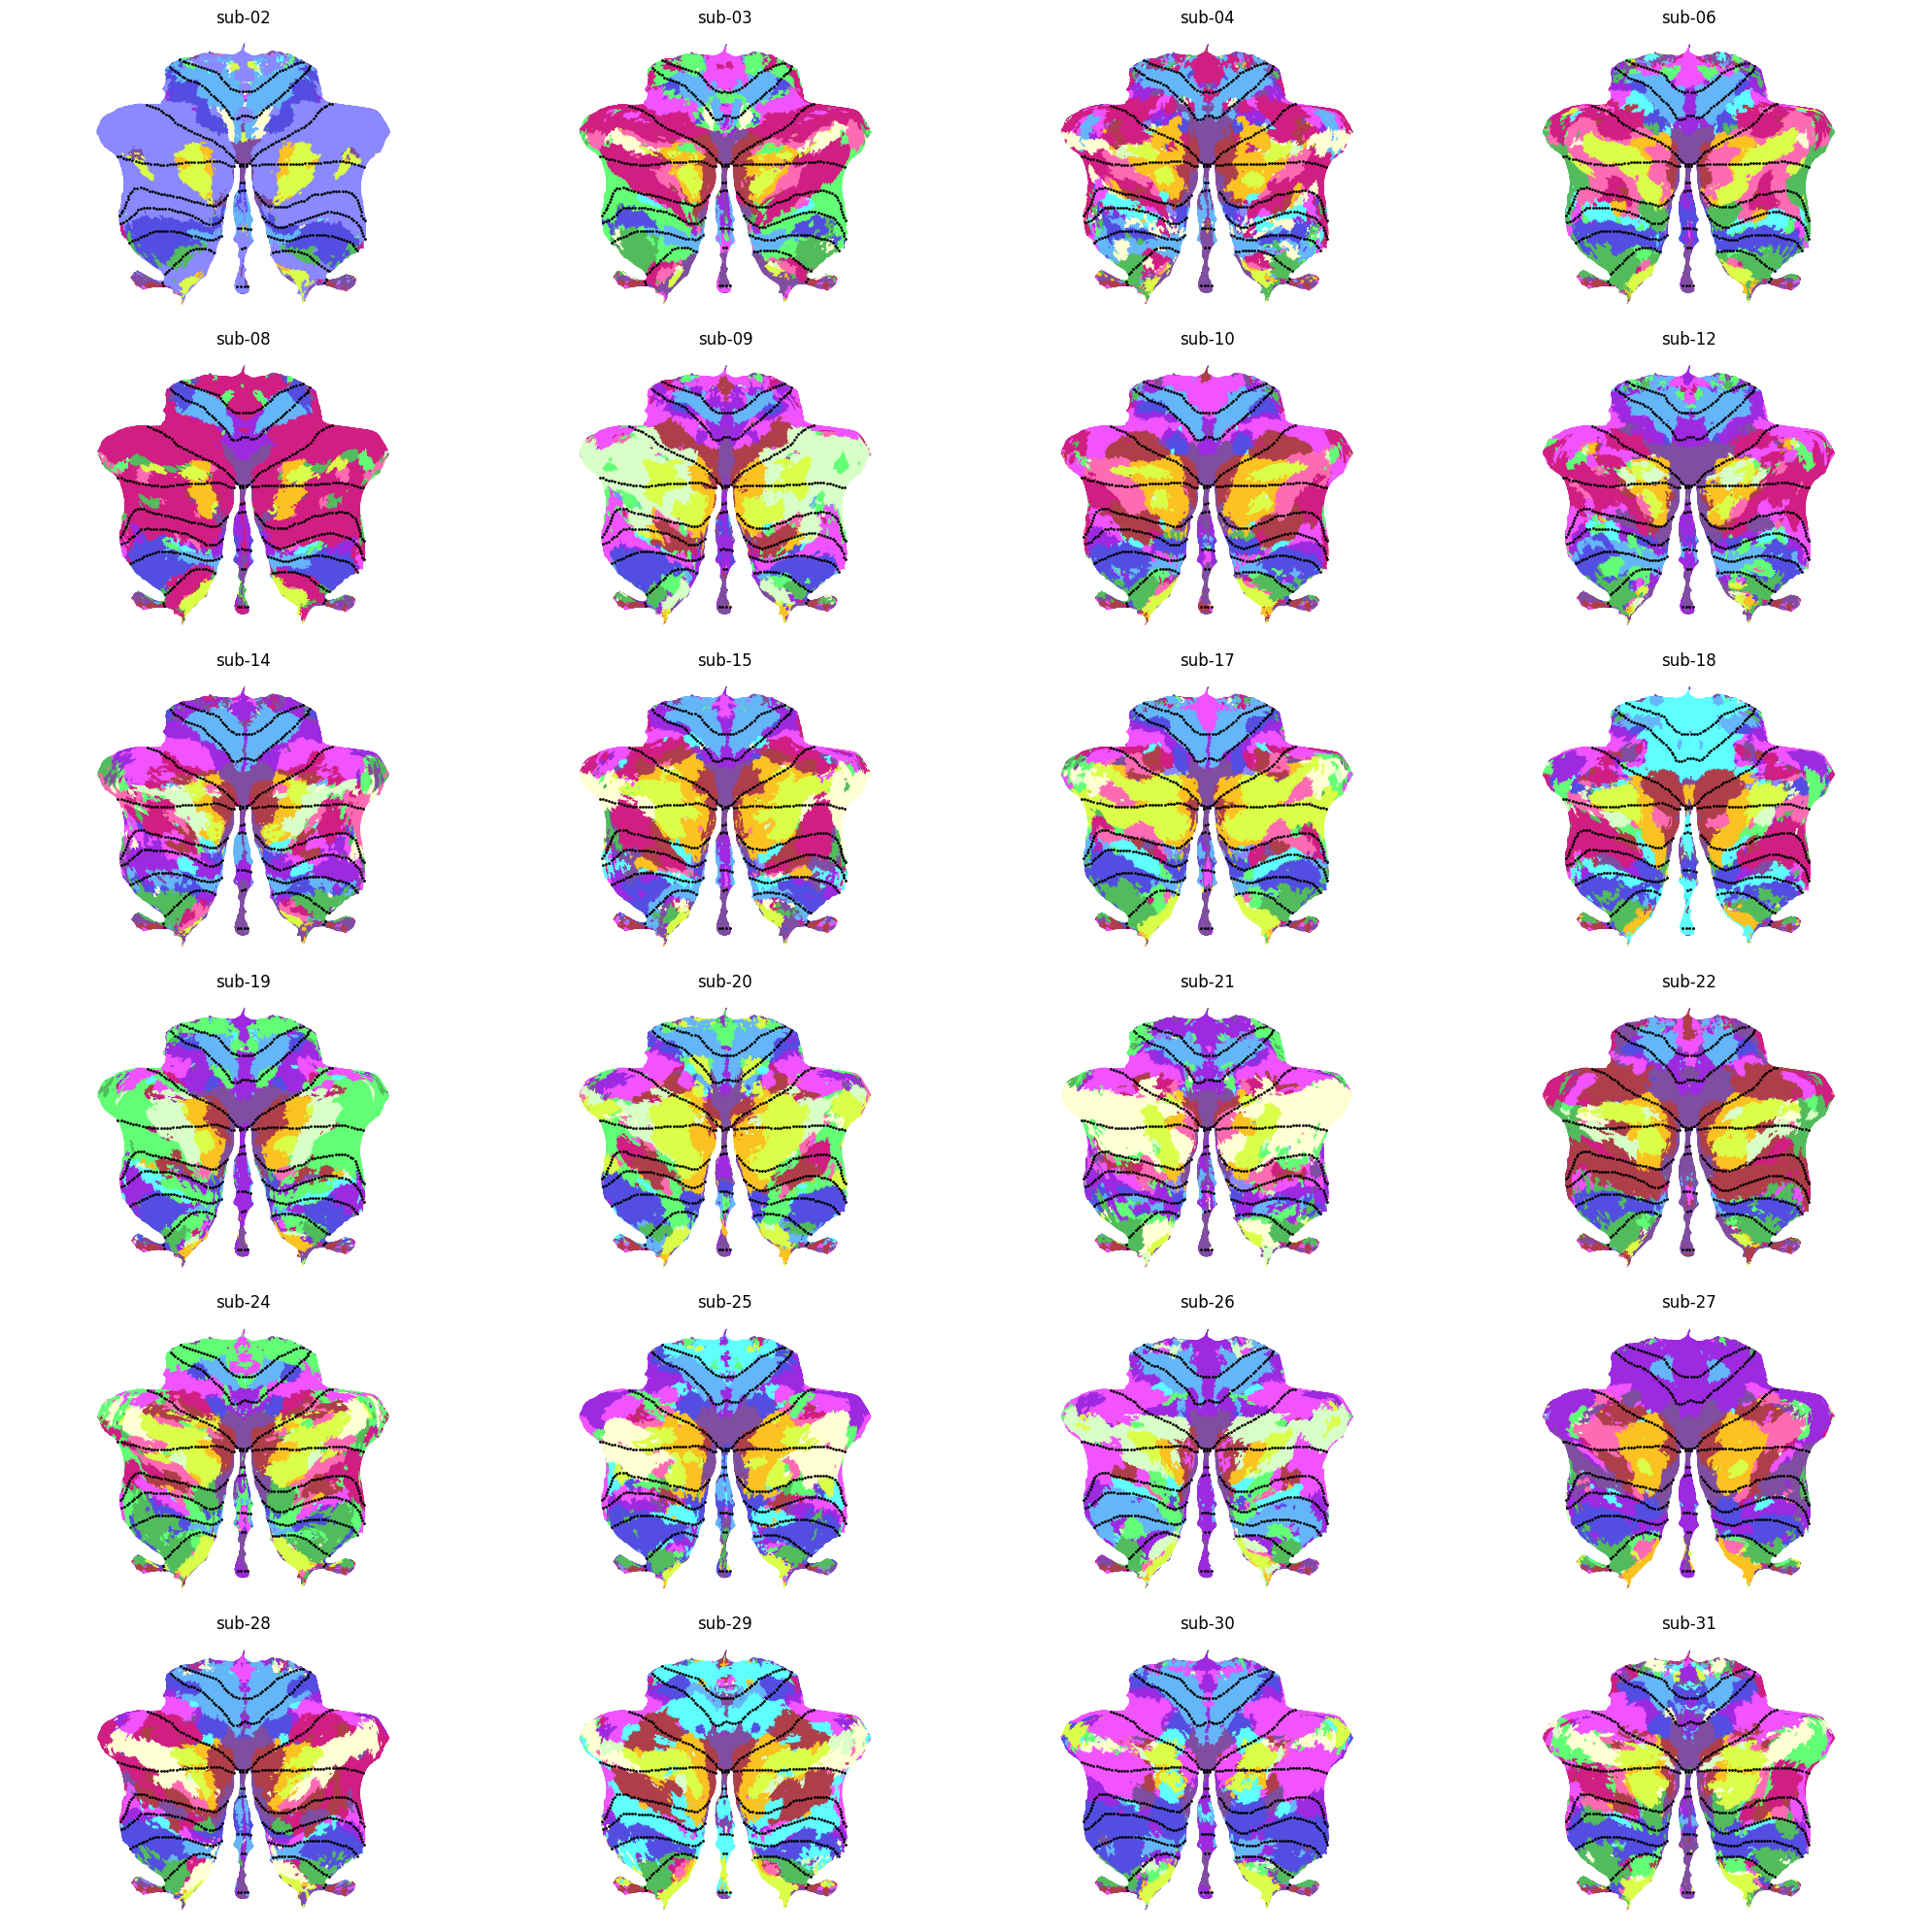

In [70]:
T = pd.read_csv(f'{data_dir}/MDTB/participants.tsv', delimiter='\t')
all_participants = T.participant_id.tolist()

plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par.cpu().numpy(), atlas=space.name, grid=(6, 4),
                cmap=cmap, dtype='prob',
                titles=all_participants)

figure_dir = paths.set_figure_dir()
plt.savefig(f'{figure_dir}/indiv_parcellations_mdtb-task.png')

<Axes: >

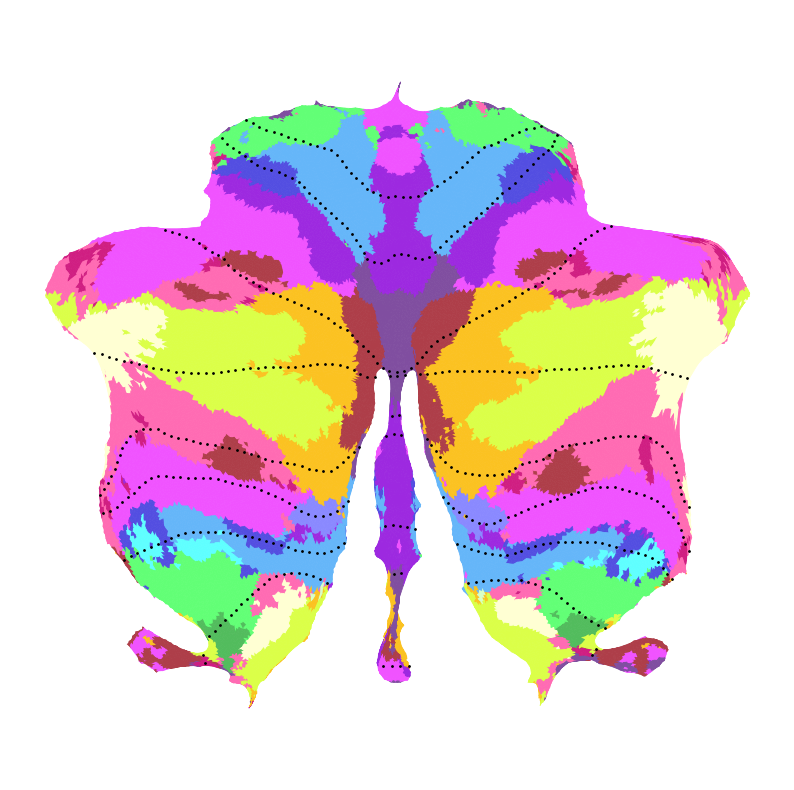

In [41]:
plt.figure(figsize=(10,10))
plot_data_flat(U, atlas=space.name,
                cmap=cmap, dtype='prob')

# Fit the resting-state data

## Load resting-state data

### Type: Net69Run

In [12]:
T = pd.read_csv(f'{data_dir}/MDTB/participants.tsv', delimiter='\t')
participants = T.participant_id
rest_subjects = participants[T['ses-rest'] == 1].tolist()

In [60]:
# Step 4b.1: Load the data into 3d tensor
data_69, info_69, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, sess='ses-rest', type='Net69Run', subj=rest_subjects)

# Step 4b.2: Prepare the data into the right format
tdata_69, cond_v, part_v, sub_ind = fm.prep_datasets(data_69, info_69.sess,
                                                  info_69['net_id'].values,
                                                  info_69['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [61]:
indiv_par_rest, _, _ = fm.get_indiv_parcellation(ar_model, tdata_69, space, cond_v, part_v, sub_ind, Vs=None, sym_type = sym_type)

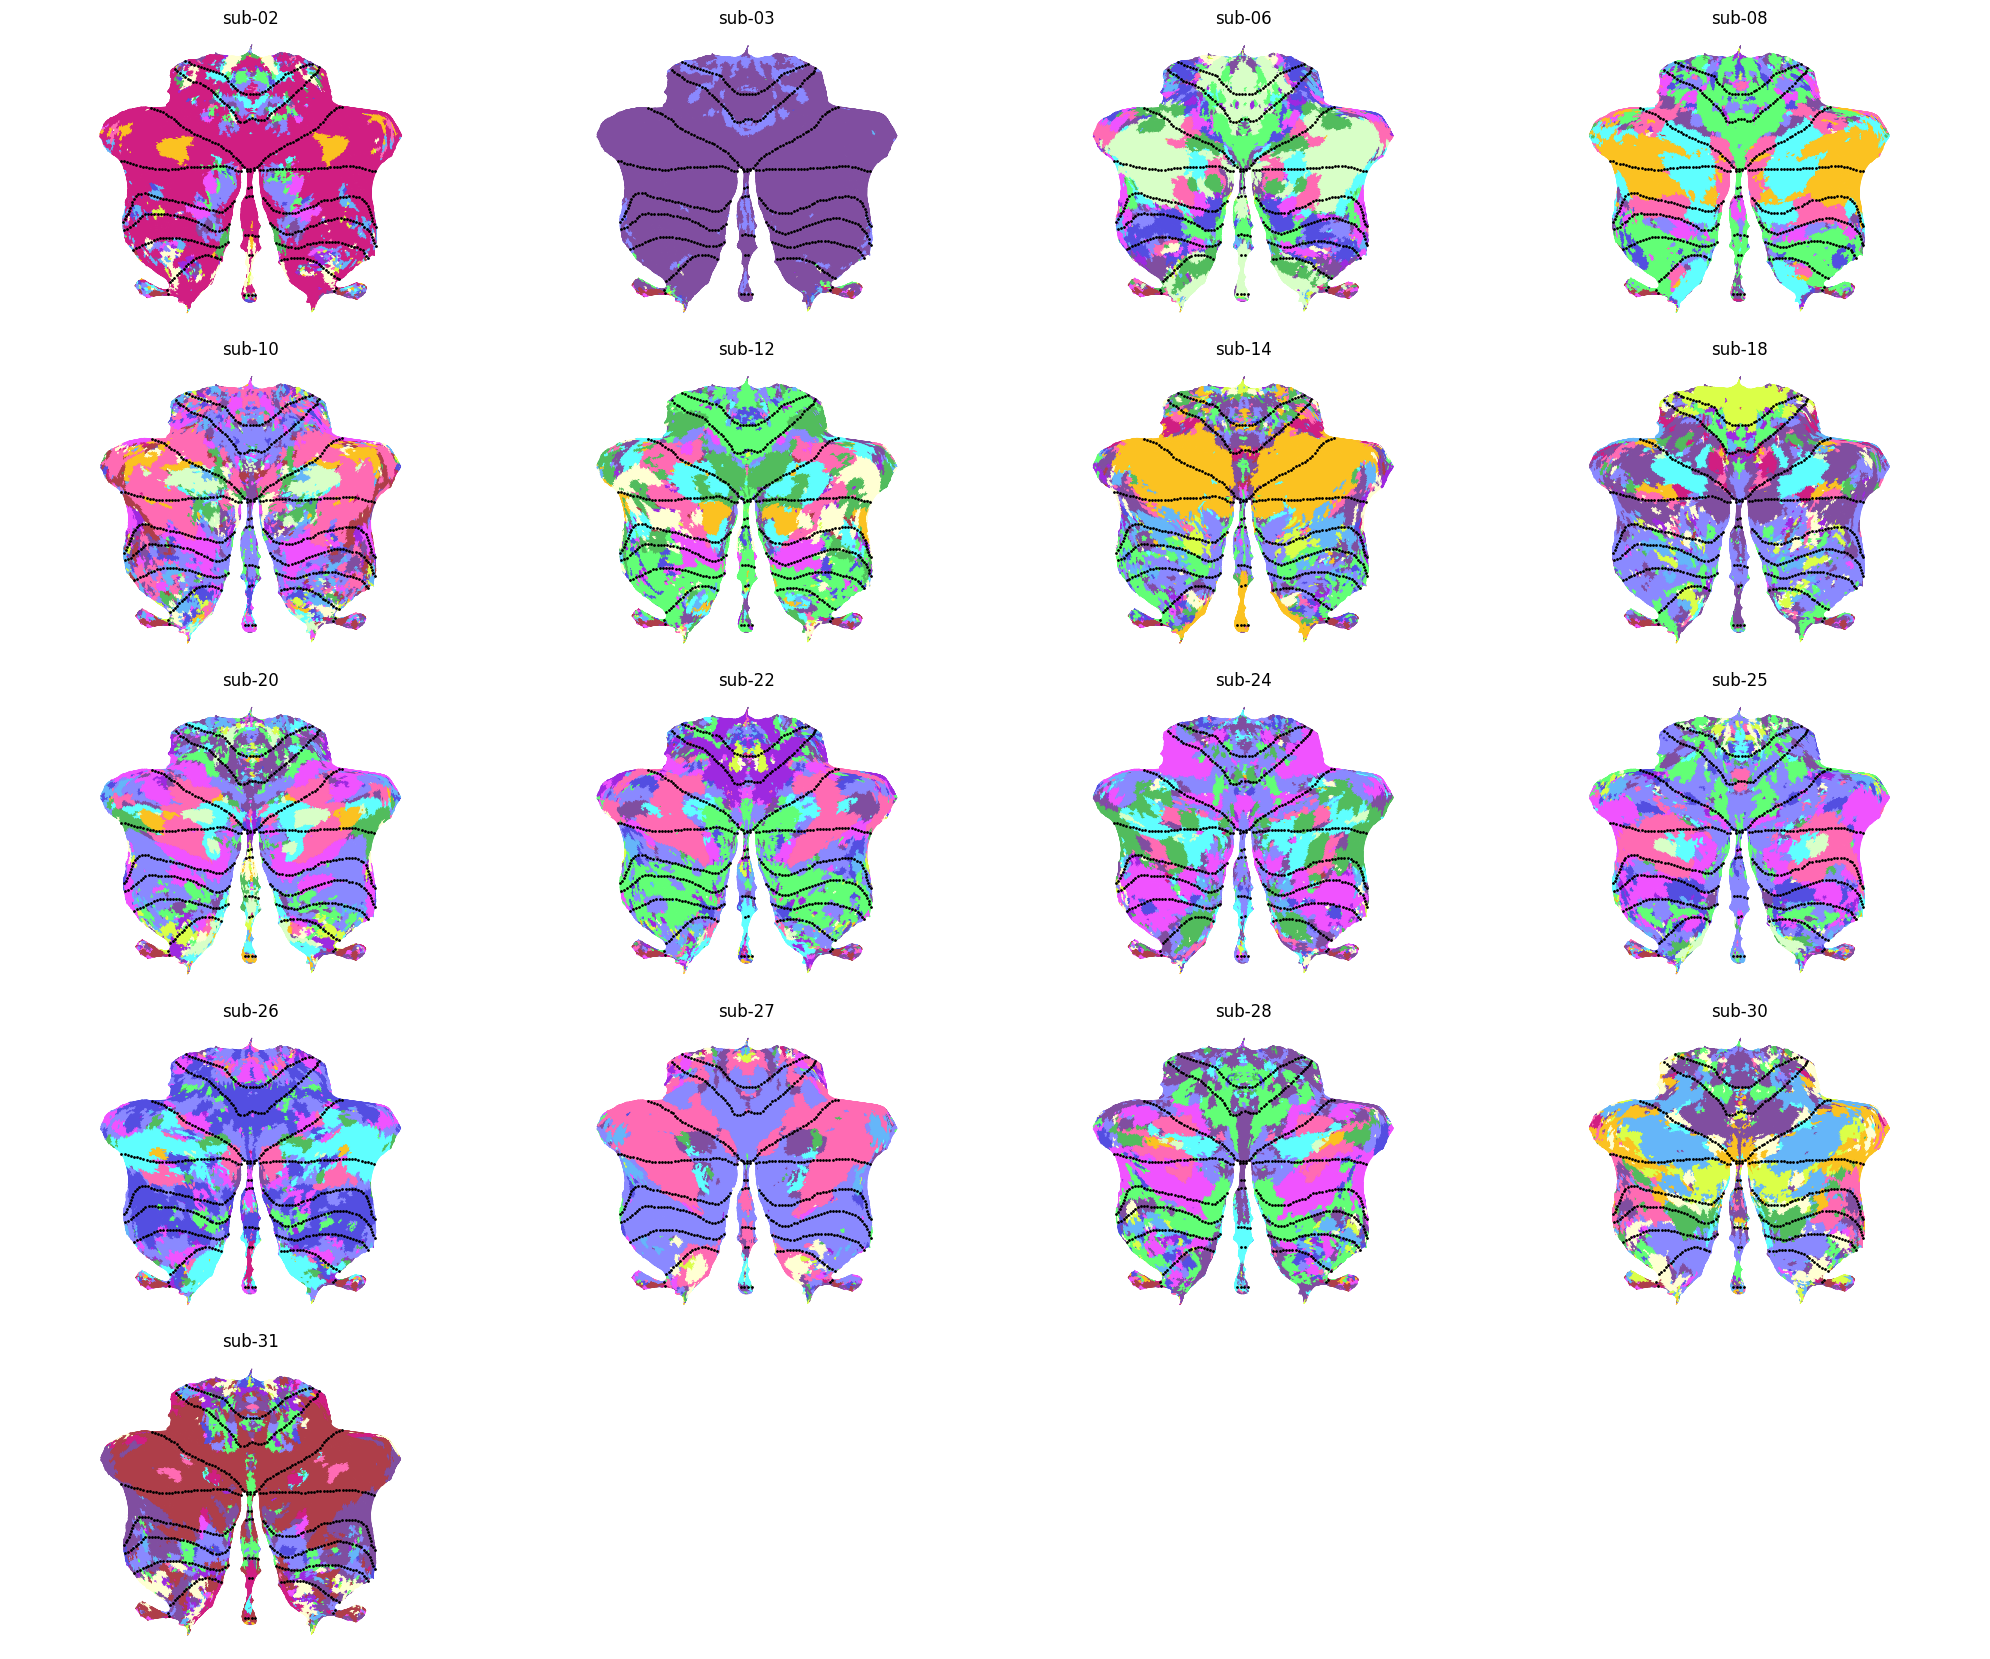

In [68]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_rest.cpu().numpy(), atlas=space.name, grid=(6, 4),
                cmap=cmap, dtype='prob',
                titles=rest_subjects)
plt.savefig(f'{figure_dir}/indiv_parcellations_mdtb-rest.png')

### Type: Ico42Run

In [15]:
# Step 4b.1: Load the data into 3d tensor
data_ico, info_ico, tds = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, sess='ses-rest', type='Ico42Run', subj=rest_subjects)

# Step 4b.2: Prepare the data into the right format
tdata_ico, cond_v, part_v, sub_ind = fm.prep_datasets(data_ico, info_ico.sess,
                                                  info_ico['net_id'].values,
                                                  info_ico['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [46]:
indiv_par_rest_ico, _, _ = fm.get_indiv_parcellation(ar_model, atlas=space, train_data=tdata_ico, cond_vec=cond_v, part_vec=part_v, subj_ind=sub_ind, Vs=None, sym_type=sym_type)

NameError: name 'figure_dir' is not defined

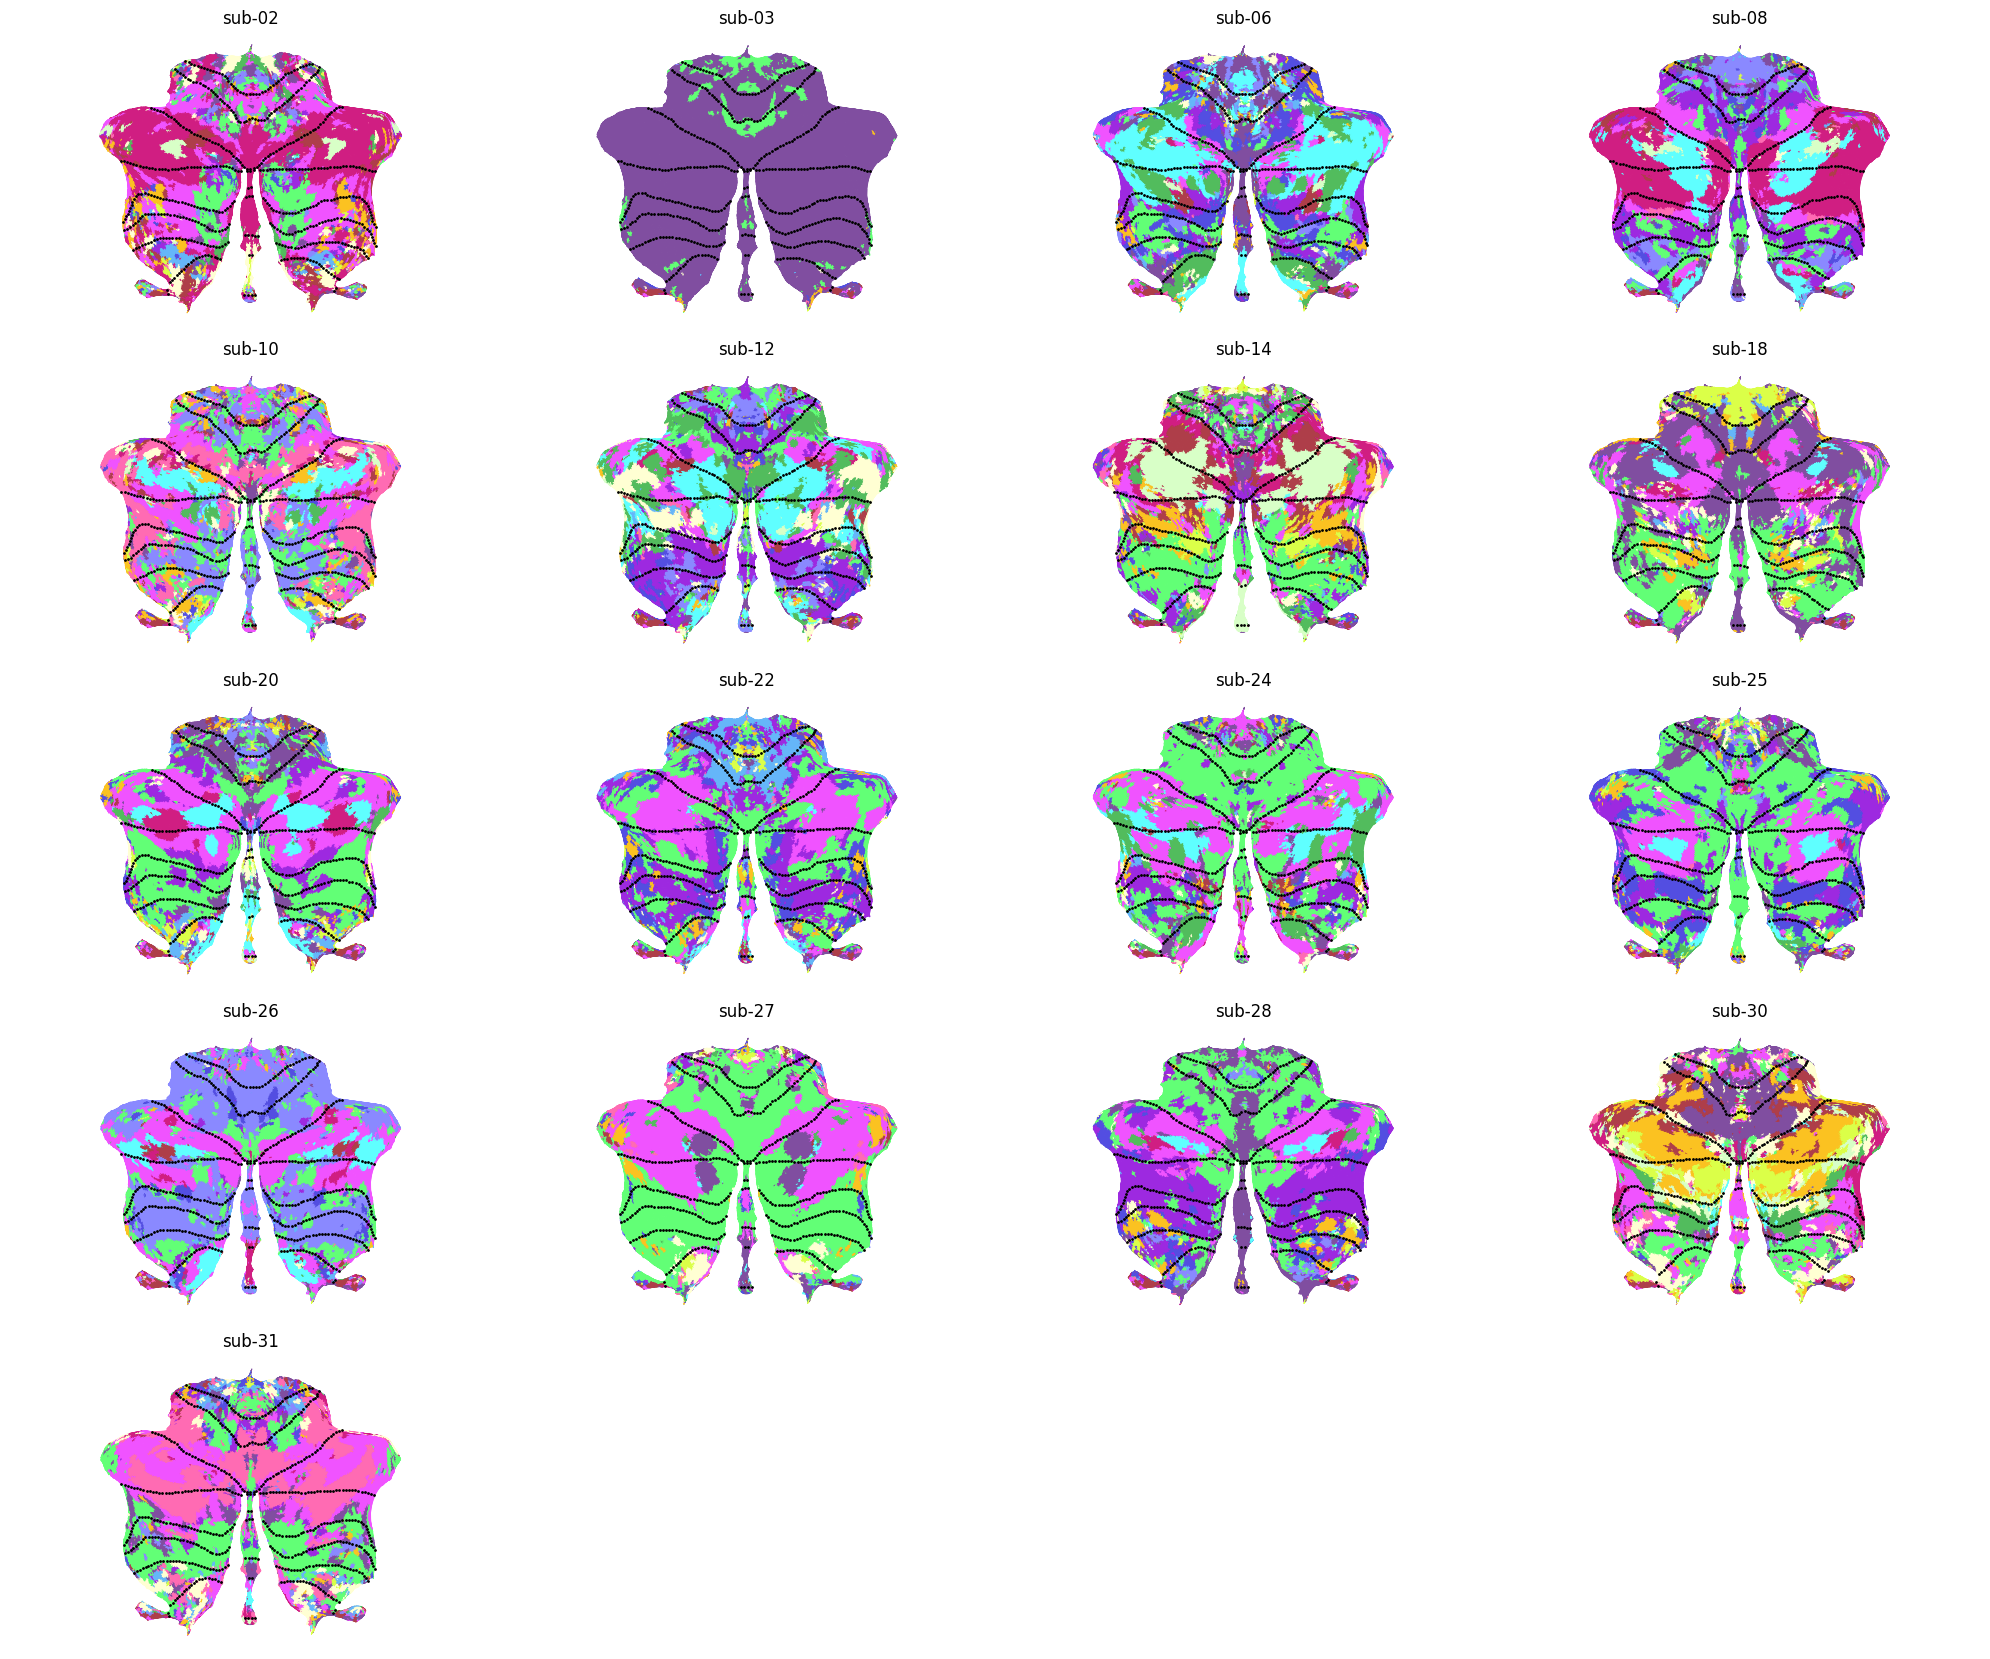

In [47]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_rest_ico.cpu().numpy(), atlas=space.name, grid=(6, 4),
                cmap=cmap, dtype='prob',
                titles=rest_subjects)


### Type: Net67Run

In [13]:
# Step 4b.1: Load the data into 3d tensor
data_67, info_67, tds_67 = ds.get_dataset(data_dir, 'MDTB', atlas=space.name, sess='ses-rest', type='Net67Run', subj=rest_subjects)

# Step 4b.2: Prepare the data into the right format
tdata_67, cond_v, part_v, sub_ind = fm.prep_datasets(data_67, info_67.sess,
                                                  info_67['net_id'].values,
                                                  info_67['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [14]:

# Step 4b.2: Prepare the data into the right format
tdata_67, cond_v, part_v, sub_ind = fm.prep_datasets(data_67, info_67.sess,
                                                  info_67['net_id'].values,
                                                  info_67['half'].values,
                                                  join_sess=False,
                                                  join_sess_part=False)

In [16]:
indiv_par_rest_net67, _, _ = fm.get_indiv_parcellation(ar_model, atlas=space, train_data=tdata_ico, cond_vec=cond_v, part_vec=part_v, subj_ind=sub_ind, Vs=None, sym_type=sym_type)

NameError: name 'figure_dir' is not defined

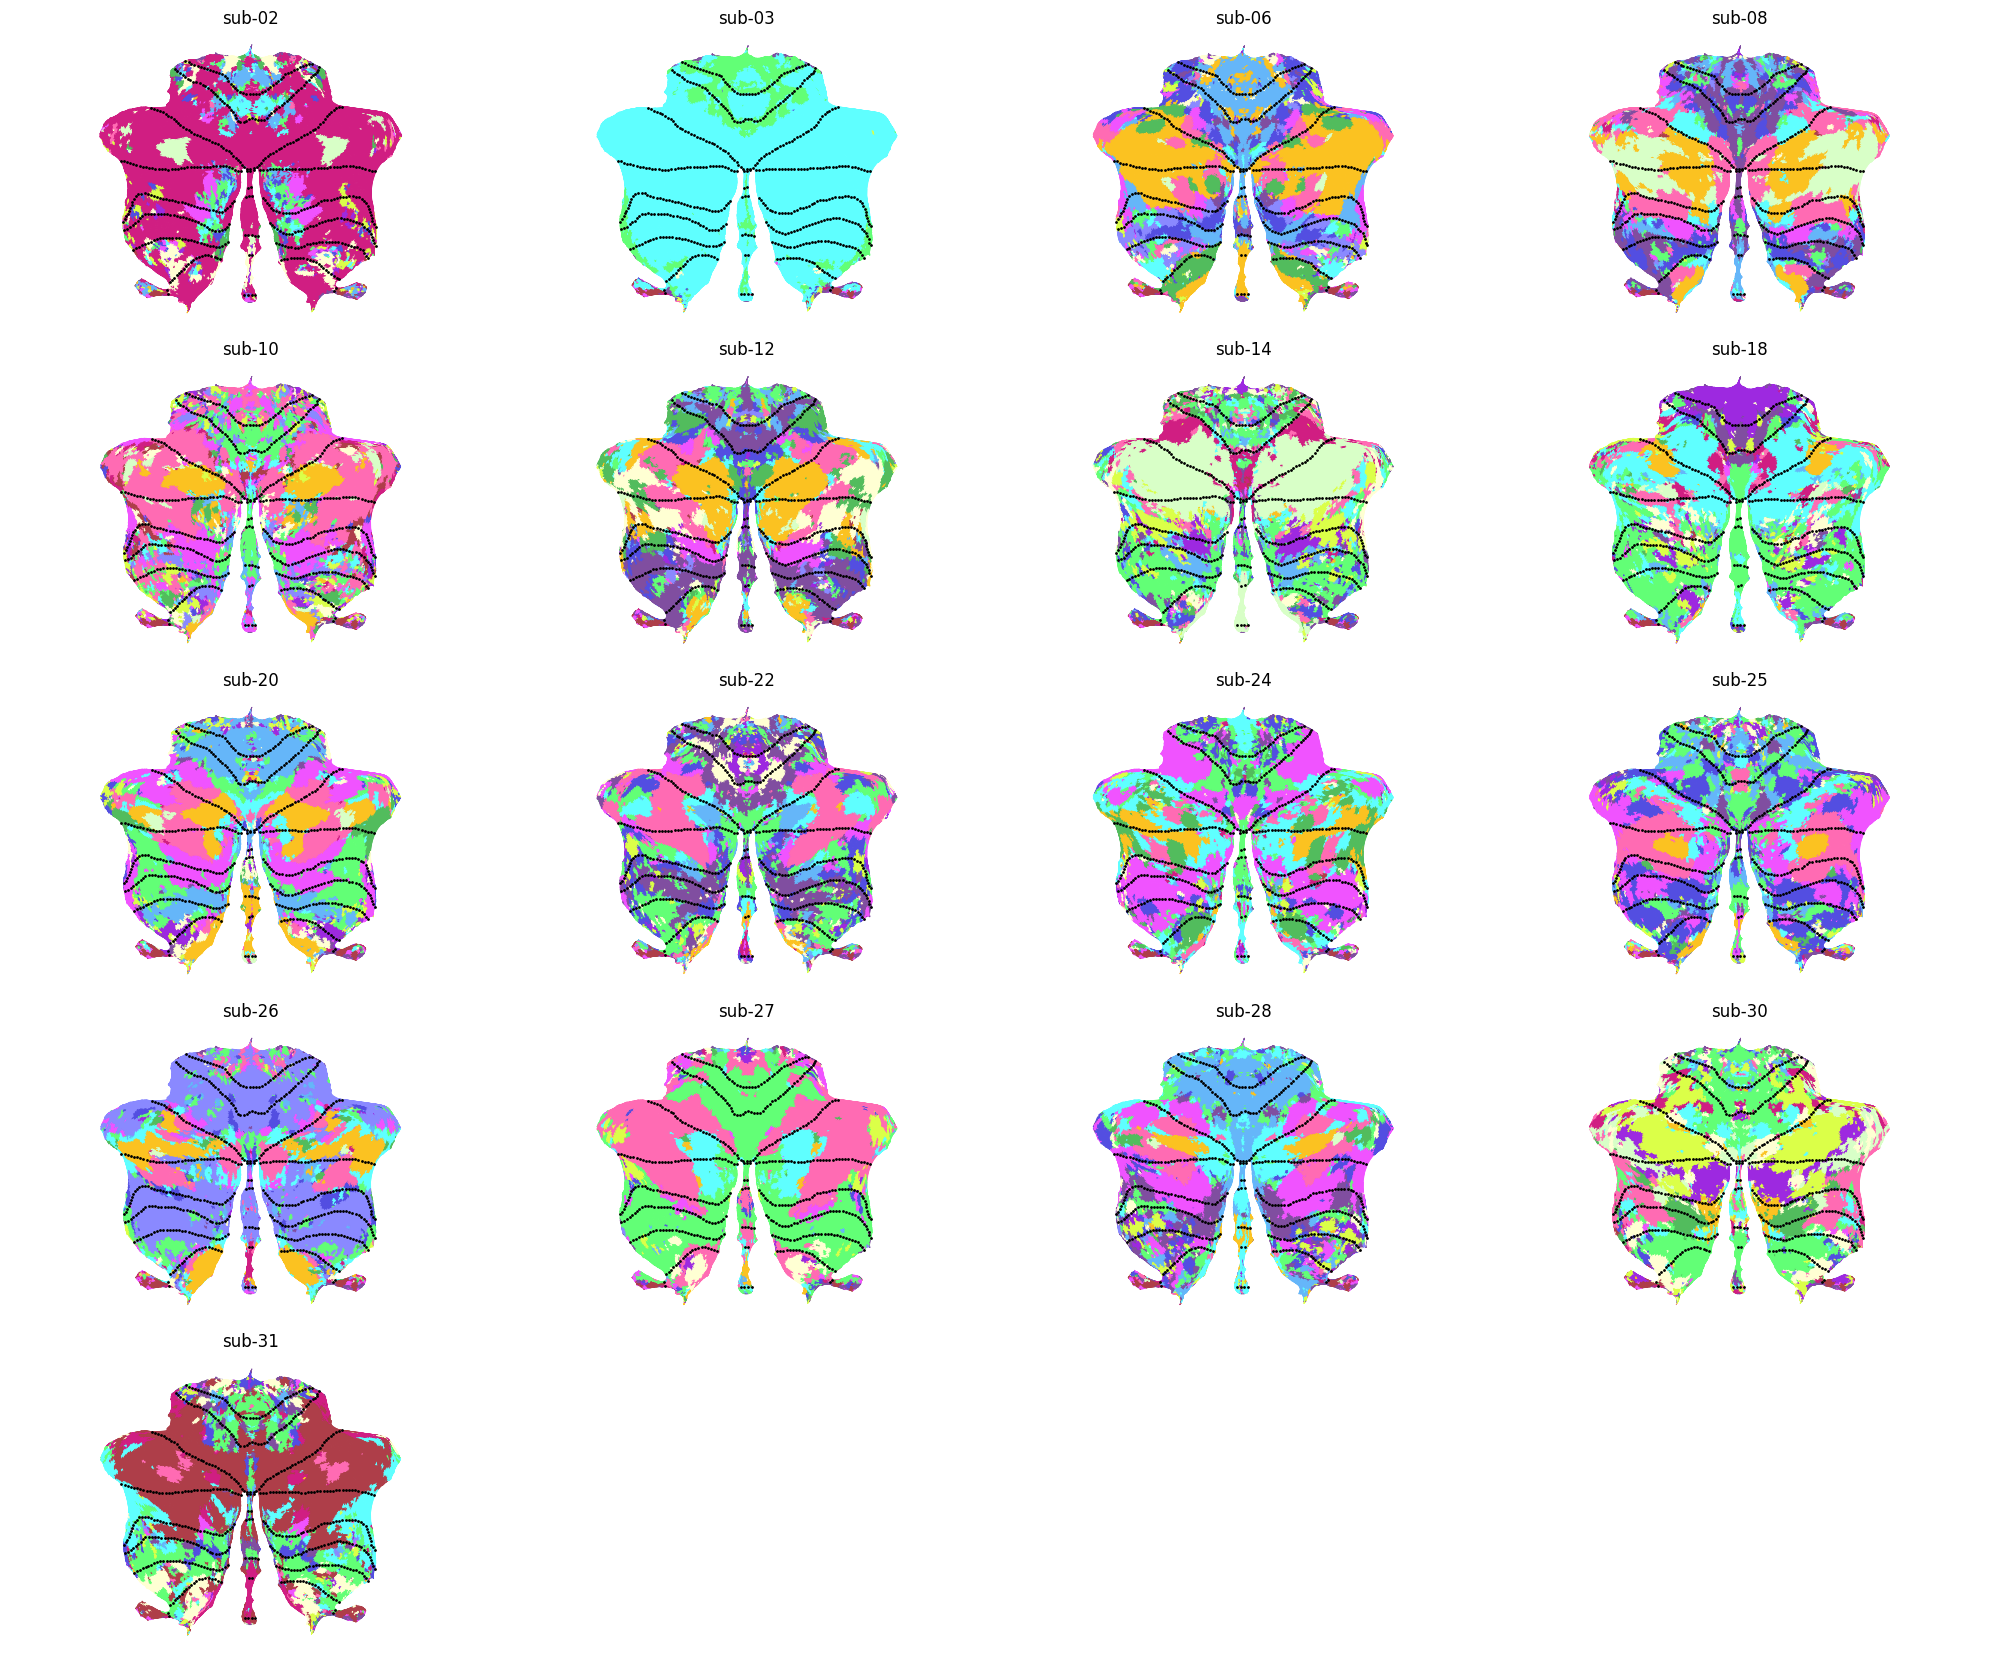

In [17]:
plt.figure(figsize=(20,20))
plot_multi_flat(indiv_par_rest_net67.cpu().numpy(), atlas=space.name, grid=(6, 4),
                cmap=cmap, dtype='prob',
                titles=rest_subjects)
plt.savefig(f'{figure_dir}/indiv_parcellations_mdtb-rest-net67.png')